In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


# Import necessary libraries

In [22]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler

# Import the dataset and describe it

In [23]:
df=pd.read_csv("/kaggle/input/iris/Iris.csv")
df=df.drop(columns='Id')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.90000

# Label Encoding and Scaling the Data

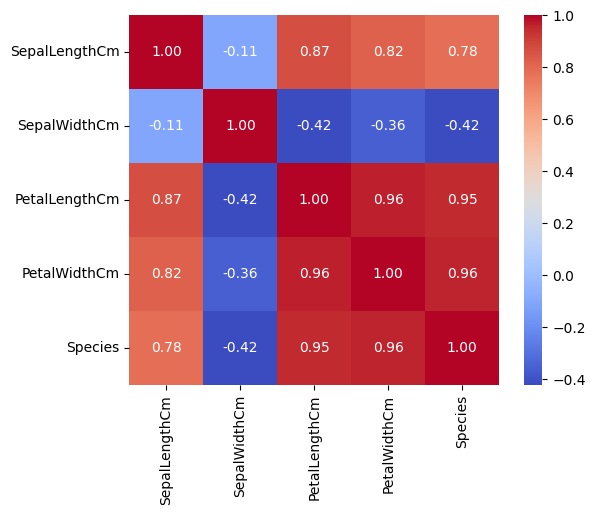

In [24]:
le=LabelEncoder()
df['Species']=le.fit_transform(df['Species'])
numeric_cols=list(df.select_dtypes(include='float64').columns)
mms=MinMaxScaler()
scaled_df=pd.DataFrame(mms.fit_transform(df[numeric_cols]),columns=numeric_cols)
scaled_df['Species']=df['Species']
sns.heatmap(scaled_df.corr(),cmap='coolwarm',annot=True,fmt='.2f',square=True)
plt.show()

# Training the base model(Logistic Regression)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc,confusion_matrix as cm
x=df.drop(columns='Species')
y=df['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
log=LogisticRegression()
log.fit(x_train,y_train)
y_pred1=log.predict(x_test)
print("Accuracy score:",acc(y_test,y_pred1))
print("Confusion matrix:\n",cm(y_test,y_pred1))

Accuracy score: 1.0
Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# Training KNeighborsClassifier with 3,5,7,9 neighbors and evaluation of Model

In [26]:
from sklearn.neighbors import KNeighborsClassifier
for i in range(3,10,2):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred2=knn.predict(x_test)
    print("Metrics for KNN for",i,"neighbors:")
    print("Accuracy score:",acc(y_test,y_pred2))
    print("Confusion matrix:\n",cm(y_test,y_pred2))

Metrics for KNN for 3 neighbors:
Accuracy score: 1.0
Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Metrics for KNN for 5 neighbors:
Accuracy score: 1.0
Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Metrics for KNN for 7 neighbors:
Accuracy score: 0.9666666666666667
Confusion matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
Metrics for KNN for 9 neighbors:
Accuracy score: 1.0
Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
